In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import smarts_cerebellum.globals as gl

df = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'patients_lme_DTI.tsv'), sep = '\t')
df['Week'] = df['week'].str.extract(r'(\d+)') # get numeric values
df['region_bilat'] = df['regionname'].str[:3]


df['side'] = 'ipsilesional'
is_cst=df['region_bilat'] == 'CST'
df.loc[is_cst & (df.regionname.str[-1] == 'L'), 'side'] = 'contralesional'
df.loc[~is_cst & (df.regionname.str[-1] == 'L'), 'side'] = 'contralesional'

# sort weeks!!
df['Week'] = df['Week'].astype(int)
df=df.sort_values('Week')


# observed values
obs = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI.tsv'), sep = '\t')

controls = ['CUP_1001', 'CUP_1002', 'JHP_1001', 'JHP_1002', 'JHP_1004']
metric = 'FaMap'
obs = obs[obs.metric == metric]
obs = obs[~obs.subj_id.isin(controls)]

obs['region_bilat'] = obs['Object'].str[:3]
obs['side'] = 'ipsilesional'
is_cst=obs['region_bilat'] == 'CST'
obs.loc[is_cst & (obs.Object.str[-1] == 'L'), 'side'] = 'contralesional'
obs.loc[~is_cst & (obs.Object.str[-1] == 'L'), 'side'] = 'contralesional'

/localscratch/tmp/ipykernel_29018/3411066688.py:24: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  obs = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI.tsv'), sep = '\t')


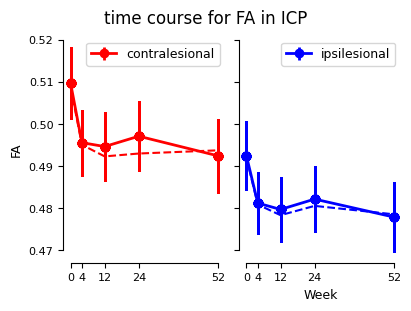

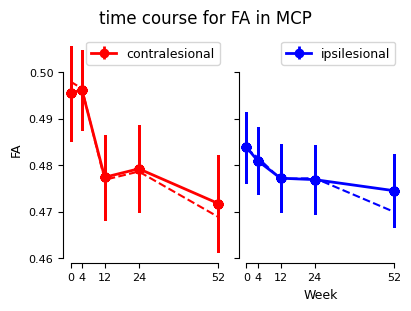

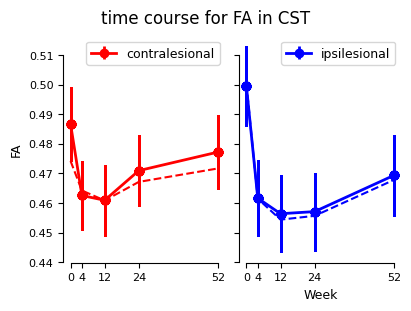

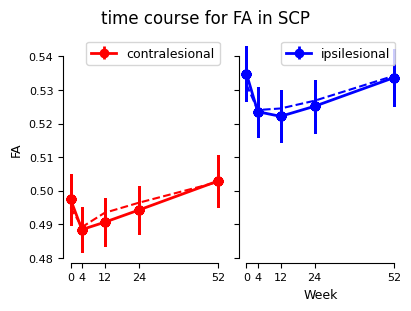

In [2]:
colours = ['red', 'blue']
for r, region in enumerate(df.region_bilat.unique()):
    df_lme = df[(df.region_bilat == region)].sort_values('Week')
    df_obs = obs[(obs.region_bilat == region)].sort_values('week_num')

    fig, axs = plt.subplots(1,2, figsize=(4,3), sharey = True, constrained_layout=True)

    for i, side in enumerate(df.side.unique()):
        ax = axs[i]

        df_lme_side = df_lme[df_lme.side == side].sort_values("Week")
        df_obs_side = df_obs[df_obs.side == side].sort_values("week_num")
        df_obs_side = df_obs_side.groupby(['week_num']).agg({'Mean': 'mean'}).reset_index()

        ax.errorbar(x = df_lme_side['Week'], y = df_lme_side['beta'], yerr = df_lme_side['se'], fmt = '-o', linewidth = 2, color = colours[i], label = side)
        ax.plot(df_obs_side['week_num'], df_obs_side['Mean'], linestyle = '--', color = colours[i])

    for ax in axs:
        ax.legend()
        ax.set_xticks(gl.weeks)
        axs[0].set_ylabel("FA")
        axs[1].set_xlabel("Week")


    plt.suptitle(f"time course for FA in {region}")
    sns.despine(trim = True)
    plt.show()
